# Southern California House Price Prediction
### Tabular and Image-Based Regression
This notebook explores the SoCal house dataset, builds a tabular baseline model, then trains an image + tabular deep learning model.

## 1. Setup and Imports

In [1]:
import numpy as np
import pandas as pd

import os
import random

from PIL import Image
import itertools
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler

import cv2

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Model, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization, SpatialDropout2D, Concatenate
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l1, l2
from tensorflow.keras.losses import CategoricalCrossentropy

import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)


## 2. Data Loading
Load the Kaggle dataset when available. If the notebook is running locally, use the files in the current folder.

In [2]:
try:
    import kagglehub
    ted8080_house_prices_and_images_socal_path = kagglehub.dataset_download('ted8080/house-prices-and-images-socal')
    print('Data source import complete.')
except Exception:
    ted8080_house_prices_and_images_socal_path = os.getcwd()
    print('Using local data folder.')


100%|██████████| 369M/369M [00:21<00:00, 18.2MB/s]

Extracting files...


Data source import complete.


In [3]:
ted8080_house_prices_and_images_socal_path

'/root/.cache/kagglehub/datasets/ted8080/house-prices-and-images-socal/versions/1'

In [4]:
data_path = ted8080_house_prices_and_images_socal_path

csv_path = os.path.join(data_path, "socal2.csv")
if not os.path.exists(csv_path):
    csv_path = os.path.join(os.getcwd(), "socal2.csv")

df = pd.read_csv(csv_path)
df


,image_id,street,citi,n_citi,bed,bath,sqft,price
0,0,1317 Van Buren Avenue,"Salton City, CA",317,3,2.0,1560,201900
1,1,124 C Street W,"Brawley, CA",48,3,2.0,713,228500
2,2,2304 Clark Road,"Imperial, CA",152,3,1.0,800,273950
3,3,755 Brawley Avenue,"Brawley, CA",48,3,1.0,1082,350000
4,4,2207 R Carrillo Court,"Calexico, CA",55,4,3.0,2547,385100
...,...,...,...,...,...,...,...,...
15469,15469,4156 Sterlingview Drive,"Moorpark, CA",227,5,4.1,4092,949000
15470,15470,4355 Avenida Prado,"Thousand Oaks, CA",372,5,3.0,2773,949900
15471,15471,12717 Koenigstein Rd Road,"Santa Paula, CA",338,3,2.0,1576,920000
15472,15472,36 Kunkle Street,"Oak View, CA",253,4,2.0,2086,997000


## 3. Basic Cleaning and Feature Engineering

In [5]:
df = df.rename(columns = {
    'citi': 'city',
    'n_citi': 'city_encoded',
    'bed': 'bedrooms',
    'bath': 'bathrooms',
})


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15474 entries, 0 to 15473
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   image_id      15474 non-null  int64  
 1   street        15474 non-null  object 
 2   city          15474 non-null  object 
 3   city_encoded  15474 non-null  int64  
 4   bedrooms      15474 non-null  int64  
 5   bathrooms     15474 non-null  float64
 6   sqft          15474 non-null  int64  
 7   price         15474 non-null  int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 967.3+ KB


In [7]:
df["bathrooms"] = df["bathrooms"].astype("int64")

In [8]:
df["Total_rooms"] = df["bathrooms"] + df["bedrooms"]

In [9]:
df["Price per Square Foot"] = df["price"] / df["sqft"]

In [10]:
df["sqft_per_room"] = df["sqft"] / df["Total_rooms"]

# clean any infinity values from division before modeling
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna().reset_index(drop=True)

### Missing Values and Duplicates

In [11]:
df.isna().sum()

,0
image_id,0
street,0
city,0
city_encoded,0
bedrooms,0
bathrooms,0
sqft,0
price,0
Total_rooms,0
Price per Square Foot,0


In [12]:
df.duplicated().sum()

np.int64(0)

## 4. Exploratory Data Analysis

### Number of houses in each city.
The dataset is not evenly distributed across cities. San Diego has the largest number of houses with **707 listings**, followed by Los Angeles with **388**, Lancaster with **312**, La Quinta with **305**, and Riverside with **274**. This means the model will see more examples from high-count cities, so city-based patterns may be learned better for those locations than for cities with only a few samples.


In [13]:
N_of_houses_per_city = df.groupby("city")["image_id"].count()
N_of_houses_per_city = N_of_houses_per_city.sort_values(ascending=False)
N_of_houses_per_city

for i in N_of_houses_per_city.index:
    print(f"{i}: {N_of_houses_per_city[i]}")

San Diego, CA: 707
Los Angeles, CA: 388
Lancaster, CA: 312
La Quinta, CA: 305
Riverside, CA: 274
Corona, CA: 257
Escondido, CA: 242
Fontana, CA: 230
Palm Springs, CA: 228
Big Bear, CA: 228
Palmdale, CA: 224
Oceanside, CA: 208
Rancho Cucamonga, CA: 199
Palm Desert, CA: 196
Murrieta, CA: 188
Paso Robles, CA: 184
San Bernardino, CA: 177
Lake Arrowhead, CA: 172
Rancho Mirage, CA: 167
Temecula, CA: 162
Chino Hills, CA: 159
Oxnard, CA: 150
Hemet, CA: 144
El Cajon, CA: 137
Chula Vista, CA: 134
Santa Ana, CA: 133
Indio, CA: 133
Chino, CA: 131
Simi Valley, CA: 126
Seal Beach, CA: 122
Camarillo, CA: 120
Victorville, CA: 120
Ventura, CA: 120
Menifee, CA: 118
Laguna Woods, CA: 118
Upland, CA: 118
Ontario, CA: 118
Fallbrook, CA: 116
Long Beach, CA: 108
Irvine, CA: 107
Thousand Oaks, CA: 106
Anaheim, CA: 106
Redlands, CA: 99
San Marcos, CA: 98
Carlsbad, CA: 98
San Luis Obispo, CA: 95
Vista, CA: 94
Atascadero, CA: 94
Orange, CA: 93
Ramona, CA: 89
Nipomo, CA: 89
Yucaipa, CA: 86
Santa Maria, CA: 84
Mis

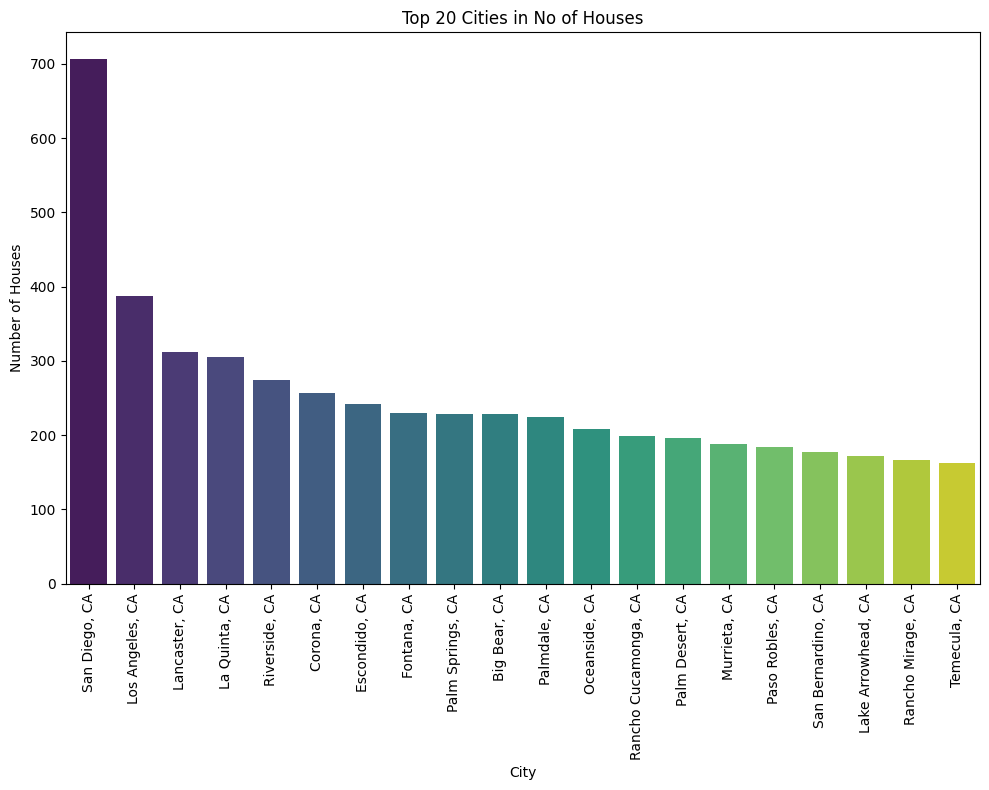

In [14]:
top_20_Cities_in_no_of_houses = N_of_houses_per_city.head(20)
top_20_Cities_in_no_of_houses

plt.figure(figsize=(10, 8))
sns.barplot(x=top_20_Cities_in_no_of_houses.index, y=top_20_Cities_in_no_of_houses.values, palette="viridis")
plt.xlabel("City")
plt.ylabel("Number of Houses")
plt.xticks(rotation=90)
plt.title("Top 20 Cities in No of Houses")
plt.tight_layout()
plt.show()

### Top 5 cities by total house prices.
Using the sum of house prices by city, the top 5 cities are **San Diego**, **Los Angeles**, **La Quinta**, **Palm Springs**, and **Corona**. These cities lead partly because they have many listings, not only because every house is expensive. For this reason, I also checked average price by city separately to understand price level without the effect of listing count.


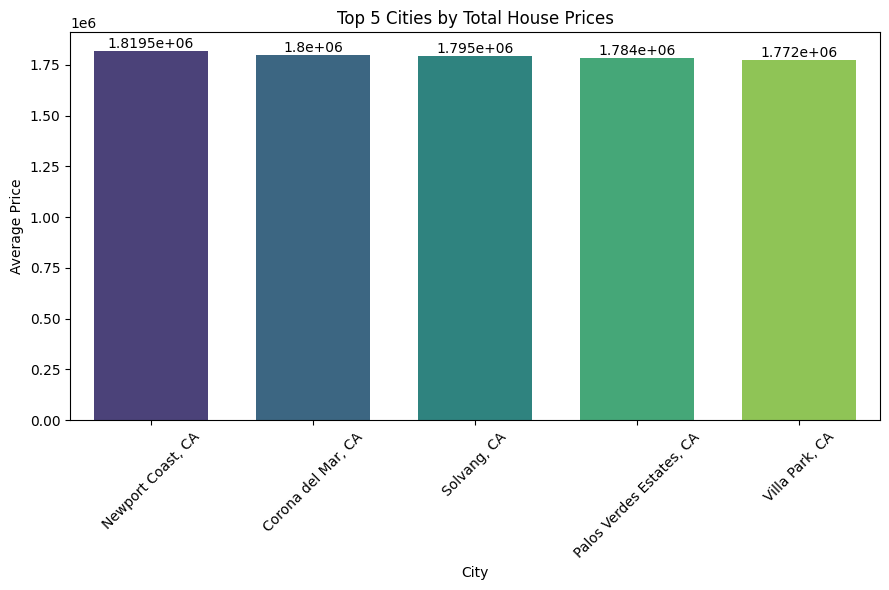

In [15]:
Top_5_cities_by_total_house_prices = df.groupby("city")["price"].mean().sort_values(ascending=False).head(5)
Top_5_cities_by_total_house_prices

plt.figure(figsize=(9, 6))

ax = sns.barplot(x=Top_5_cities_by_total_house_prices.index, y=Top_5_cities_by_total_house_prices.values, palette="viridis", width=0.7)
for i in ax.containers:
  ax.bar_label(i)

plt.xlabel("City")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.title("Top 5 Cities by Total House Prices")
plt.tight_layout()
plt.show()

### Streets with the largest number of houses.
The street with the highest count is **Address not provided** with **23 listings**, which is not a real street and should be treated carefully. The next highest streets include **1930 W San Marcos Blvd** with **8 listings** and **65565 Acoma Avenue** with **7 listings**. This shows that the street column contains useful location information, but it also has noisy or missing values.


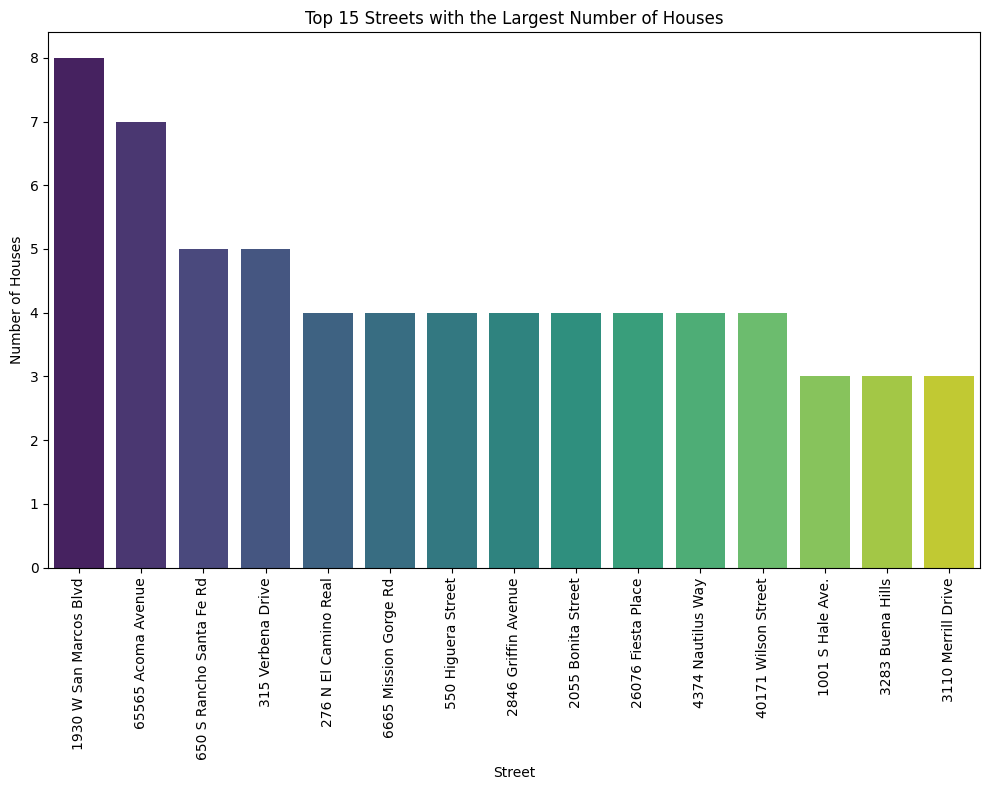

In [16]:
Streets_per_house = df.pivot_table(index="street", values="image_id", aggfunc="count").sort_values(by="image_id", ascending=False)
Streets_per_house = Streets_per_house.drop("Address not provided", errors= "ignore")

top_15_Streets_per_house = Streets_per_house.head(15)
top_15_Streets_per_house

plt.figure(figsize=(10, 8))
sns.barplot(x=top_15_Streets_per_house.index, y=top_15_Streets_per_house["image_id"], palette="viridis")
plt.xlabel("Street")
plt.ylabel("Number of Houses")
plt.xticks(rotation=90)
plt.title("Top 15 Streets with the Largest Number of Houses")
plt.tight_layout()
plt.show()

### Average house price in each city
Average price gives a better view of expensive locations because it removes the effect of how many houses each city has. The highest average prices appear in cities such as **Newport Coast**, **Corona del Mar**, **Solvang**, **Palos Verdes Estates**, and **Villa Park**. These cities likely represent more premium housing markets, so location is an important feature for predicting price.


In [17]:
Avg_House_price = df.groupby("city")["price"].mean().sort_values(ascending=False)
Avg_House_price

for i in Avg_House_price.index:
    print(f"{i}: {Avg_House_price[i]}")

Newport Coast, CA: 1819500.0
Corona del Mar, CA: 1799995.0
Solvang, CA: 1795000.0
Palos Verdes Estates, CA: 1784000.0
Villa Park, CA: 1771999.8
Westchester, CA: 1750000.0
Rancho Santa Fe, CA: 1724987.5555555555
West Hollywood, CA: 1679000.0
Venice, CA: 1669142.857142857
La Jolla, CA: 1653508.95
El Segundo, CA: 1648640.0
San Marino, CA: 1643250.0
Playa del Rey, CA: 1622000.0
Cardiff, CA: 1616333.3333333333
Valley Village, CA: 1593600.0
Beverly Hills, CA: 1585750.0
Del Mar, CA: 1577181.8181818181
Toluca Lake, CA: 1549000.0
Hermosa Beach, CA: 1499000.0
Newport Beach, CA: 1487798.9523809524
Coronado, CA: 1486999.8333333333
Solana Beach, CA: 1483181.8181818181
Sherman Oaks, CA: 1481485.7142857143
Rancho Palos Verdes, CA: 1476790.0
Lake Sherwood, CA: 1472800.0
Redondo Beach, CA: 1430833.3333333333
Santa Monica, CA: 1422500.0
Arcadia, CA: 1396480.5
Laguna Beach, CA: 1380493.3333333333
Rossmoor, CA: 1363833.3333333333
Montecito, CA: 1350000.0
Westlake Village, CA: 1347822.049180328
Studio City

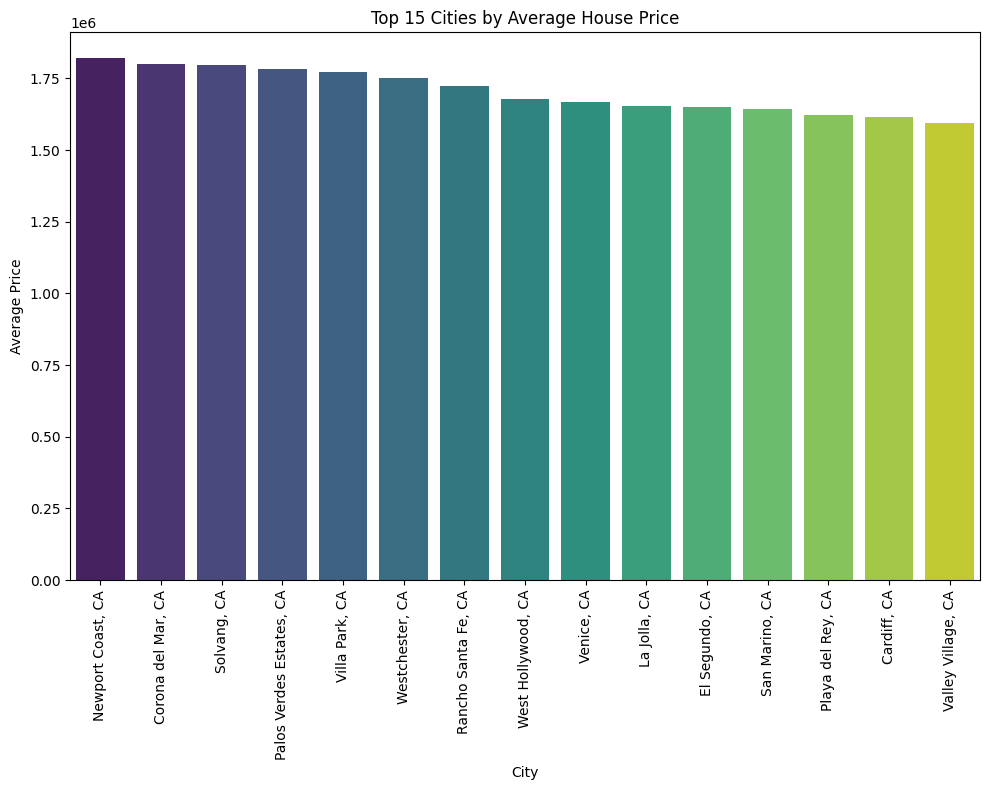

In [18]:
top_Avg_House_price = Avg_House_price.head(15)
top_Avg_House_price

plt.figure(figsize=(10, 8))
sns.barplot(x=top_Avg_House_price.index, y=top_Avg_House_price.values, palette="viridis")
plt.xlabel("City")
plt.ylabel("Average Price")
plt.xticks(rotation=90)
plt.title("Top 15 Cities by Average House Price")
plt.tight_layout()
plt.show()

### Relationship between house size (sqft) and price.

In [19]:
df[df.price == df.price.max()]

,image_id,street,city,city_encoded,bedrooms,bathrooms,sqft,price,Total_rooms,Price per Square Foot,sqft_per_room
14,14,230 Gaskell Road,"Rosamond, CA",312,1,1,1048,2000000,2,1908.396947,524.000000
3385,3385,26 Via Alcamo,"San Clemente, CA",319,6,6,5355,2000000,12,373.482726,446.250000
5245,5245,23 SANTA ROSA MOUNTAIN Lane,"Rancho Mirage, CA",300,4,3,3737,2000000,7,535.188654,533.857143
8259,8259,29025 RED GROUSE Court,"Lake Arrowhead, CA",182,4,5,4617,2000000,9,433.181720,513.000000
13551,13551,6596 Buckley Drive,"Cambria, CA",60,4,4,4499,2000000,8,444.543232,562.375000
14720,14720,1768 Via Aracena,"Camarillo, CA",59,5,4,4633,2000000,9,431.685733,514.777778


In [20]:
df[df.price == df.price.min()]

,image_id,street,city,city_encoded,bedrooms,bathrooms,sqft,price,Total_rooms,Price per Square Foot,sqft_per_room
22,22,6005 N charmain,"Bakersfield, CA",24,3,2,1087,195000,5,179.392824,217.400000
56,56,7741 Columbine Avenue,"California City, CA",57,3,2,1422,195000,5,137.130802,284.400000
70,70,21040 94th Street,"California City, CA",57,4,2,1775,195000,6,109.859155,295.833333
82,82,2213 Zermatt Drive,"Pine Mountain Club, CA",282,2,1,783,195000,3,249.042146,261.000000
743,743,45656 247th St E,"Lancaster, CA",193,1,1,416,195000,2,468.750000,208.000000
3415,3415,13400 El Dorado Drive,"Seal Beach, CA",343,2,1,718,195000,3,271.587744,239.333333
3422,3422,1301 Skokie Road,"Seal Beach, CA",343,2,1,750,195000,3,260.000000,250.000000
5326,5326,16010 Edgewater Lane,"Moreno Valley, CA",228,4,2,2319,195000,6,84.087969,386.500000
5391,5391,32489 WILDOMAR Road,"Lake Elsinore, CA",185,3,2,1584,195000,5,123.106061,316.800000
5428,5428,670 Mount Hood Drive,"Hemet, CA",141,2,2,1091,195000,4,178.735105,272.750000


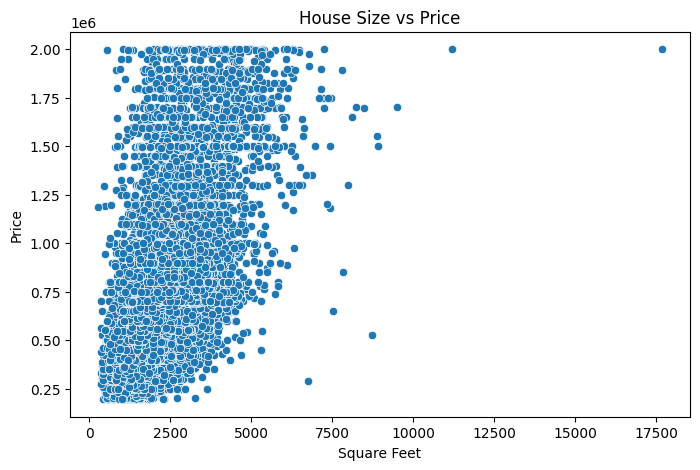

In [21]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='sqft', y='price')

plt.title('House Size vs Price')
plt.xlabel('Square Feet')
plt.ylabel('Price')
plt.show()

The scatter plot shows a clear positive relationship between **sqft** and **price**. The correlation is about **0.58**, which means larger houses usually have higher prices.

However, the relationship is not perfect. Houses with similar sizes can still have very different prices because city, street, number of rooms, house condition, and visual appearance can also affect the final price. This is why sqft is important, but it should not be used alone.


### Relationship between bedrooms and price

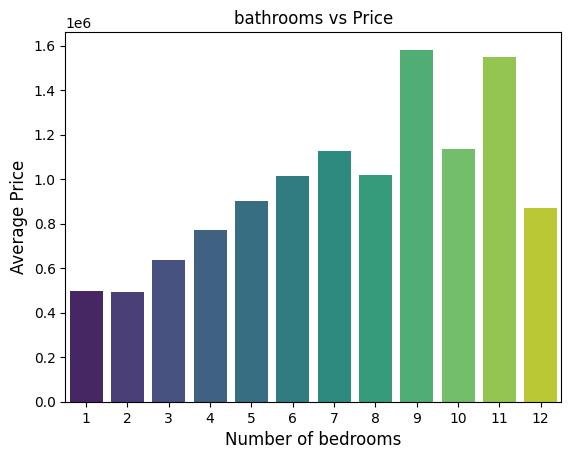

In [22]:
bedroom_per_price = df.groupby('bedrooms')['price'].mean().reset_index()
bedroom_per_price = bedroom_per_price.sort_values(ascending=False, by="price")
bedroom_per_price

sns.barplot(data=bedroom_per_price, x=bedroom_per_price["bedrooms"], y=bedroom_per_price["price"], errorbar=None, palette="viridis")

plt.title('bathrooms vs Price')
plt.xlabel('Number of bedrooms', size=12)
plt.ylabel('Average Price', size=12)

plt.ylabel('Average Price')
plt.show()

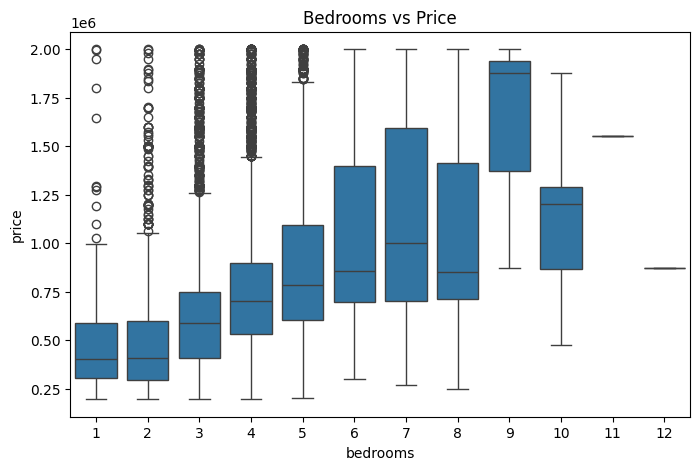

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='bedrooms', y='price')

plt.title('Bedrooms vs Price')
plt.show()

Houses with more bedrooms generally have higher prices. The correlation between bedrooms and price is about **0.35**, so the relationship is positive but weaker than sqft.

This makes sense because bedrooms often increase with house size, but the number of bedrooms alone does not fully describe the quality or location of the house. Some smaller houses in expensive cities can cost more than larger houses in cheaper areas.


### Relationship between bathrooms and price

Bathrooms also have a positive relationship with price. The correlation between bathrooms and price is about **0.47**, which is stronger than bedrooms but still not perfect.

The average price increases from houses with 1 bathroom to houses with 5 or more bathrooms, which suggests that bathrooms are a useful signal of house size and luxury level. Some extreme bathroom values look like outliers, so they should be interpreted carefully.


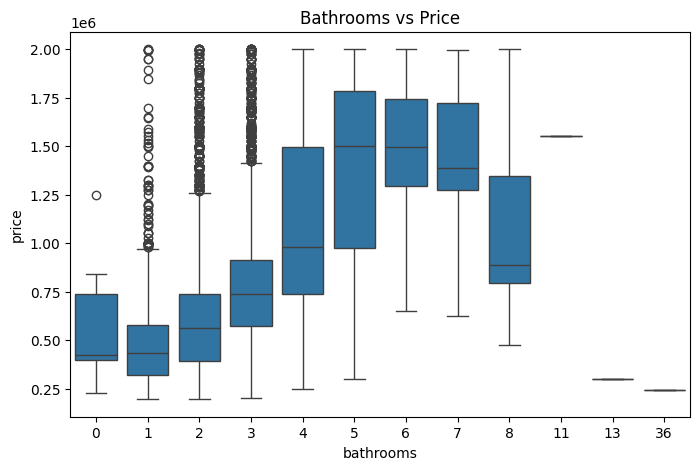

In [24]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='bathrooms', y='price')

plt.title('Bathrooms vs Price')
plt.show()

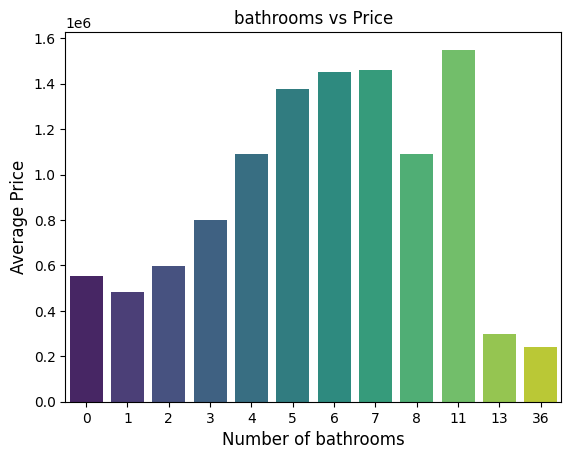

In [25]:
bathrooms_per_price = df.groupby('bathrooms')['price'].mean().reset_index()
bathrooms_per_price = bathrooms_per_price.sort_values(ascending=False, by="price")
bathrooms_per_price

sns.barplot(data=bathrooms_per_price, x=bathrooms_per_price["bathrooms"], y=bathrooms_per_price["price"], errorbar=None, palette="viridis")

plt.title('bathrooms vs Price')
plt.xlabel('Number of bathrooms', size=12)
plt.ylabel('Average Price', size=12)

plt.ylabel('Average Price')
plt.show()

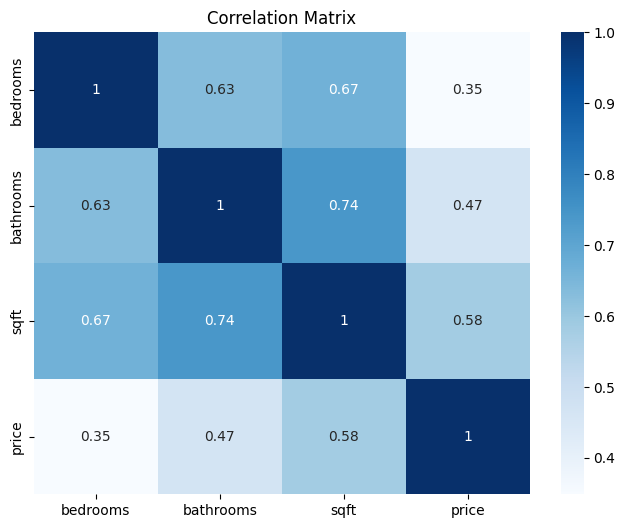

In [26]:
plt.figure(figsize=(8,6))

sns.heatmap(df[['bedrooms','bathrooms','sqft','price']].corr(), annot=True, cmap='Blues')

plt.title('Correlation Matrix')
plt.show()


### Houses Outliers

In [27]:
df.city.value_counts()

,count
city,
"San Diego, CA",707
"Los Angeles, CA",388
"Lancaster, CA",312
"La Quinta, CA",305
"Riverside, CA",274
...,...
"Hermosa Beach, CA",1
"Delano, CA",1
"Potrero, CA",1


In [28]:
df["state"] = df["city"].str.split(", ").str[-1]

In [29]:
df["state"].value_counts()

,count
state,
CA,15474


In [30]:
df = df.drop(columns=["state"])

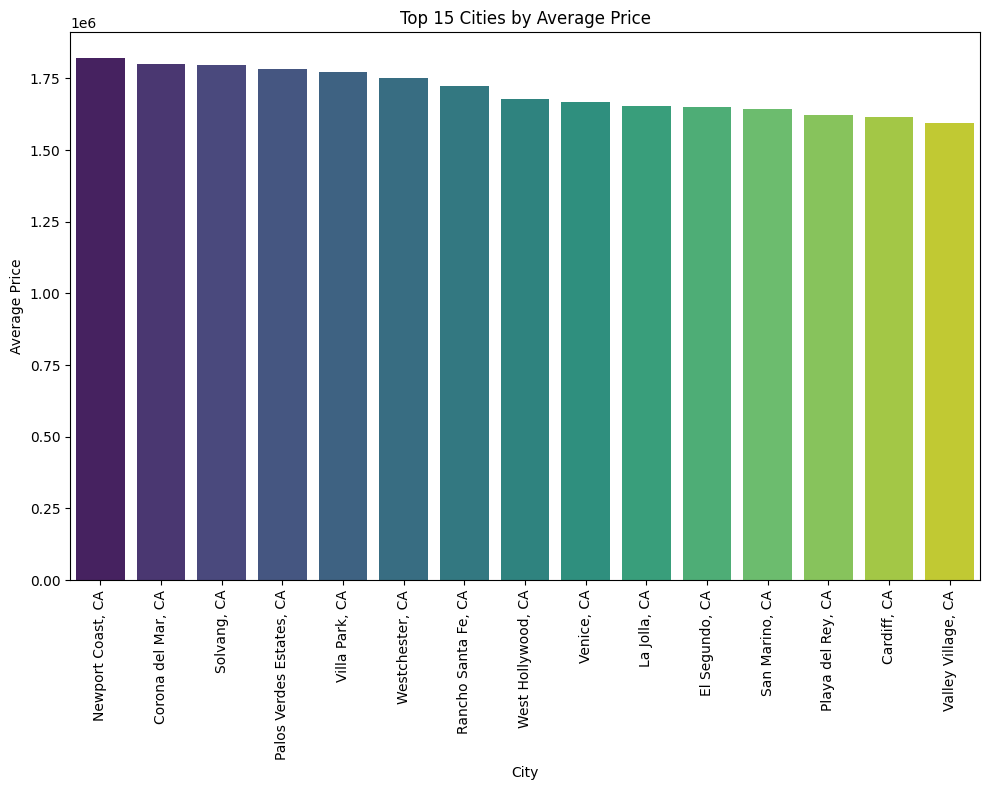

In [31]:
Top_15_city_price = df.pivot_table(index="city", values="price", aggfunc="mean").sort_values(by="price", ascending=False).head(15)
Top_15_city_price

plt.figure(figsize=(10, 8))
sns.barplot(x=Top_15_city_price.index, y=Top_15_city_price["price"], palette="viridis")
plt.xlabel("City")
plt.ylabel("Average Price")
plt.xticks(rotation=90)
plt.title("Top 15 Cities by Average Price")
plt.tight_layout()
plt.show()


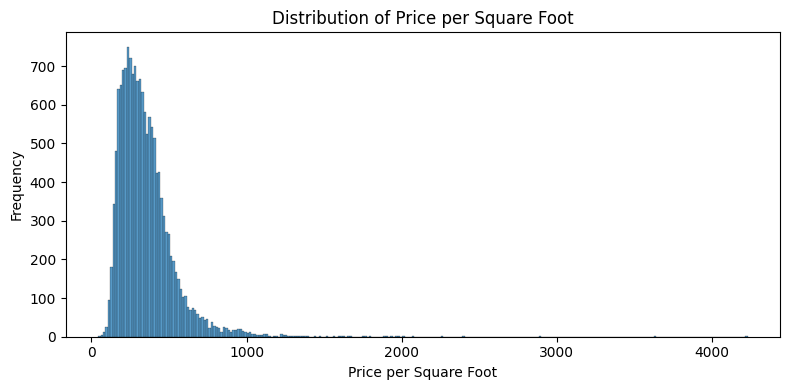

In [32]:
plt.figure(figsize=(8, 4))
sns.histplot(df["Price per Square Foot"])
plt.xlabel("Price per Square Foot")
plt.ylabel("Frequency")
plt.title("Distribution of Price per Square Foot")
plt.tight_layout()
plt.show()

In [33]:
IQR = df["Price per Square Foot"].quantile(0.75) - df["Price per Square Foot"].quantile(0.25)
IQR

lower_bound = df["Price per Square Foot"].quantile(0.25) - (1.5 * IQR)
upper_bound = df["Price per Square Foot"].quantile(0.75) + (1.5 * IQR)

print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

Lower Bound: -59.832431565783025
Upper Bound: 711.970591439268


In [34]:
luxury = df[df["Price per Square Foot"] > upper_bound]
luxury

,image_id,street,city,city_encoded,bedrooms,bathrooms,sqft,price,Total_rooms,Price per Square Foot,sqft_per_room
14,14,230 Gaskell Road,"Rosamond, CA",312,1,1,1048,2000000,2,1908.396947,524.000000
18,18,0 Oak Creek rd,"Tehachapi, CA",367,4,1,1980,1995000,5,1007.575758,396.000000
327,327,4321 BELLAIRE Avenue,"Studio City, CA",360,3,2,1671,1225000,5,733.093956,334.200000
329,329,4911 N Algoma,"Eagle Rock, CA",106,3,3,1980,1449700,6,732.171717,330.000000
333,333,8630 STANMOOR Drive,"Los Angeles, CA",207,2,2,1834,1395000,4,760.632497,458.500000
...,...,...,...,...,...,...,...,...,...,...,...
15328,15328,3817 SUNSET Lane,"Oxnard, CA",261,2,1,928,799000,3,860.991379,309.333333
15353,15353,2520 Balboa Street,"Oxnard, CA",261,3,1,1038,799999,4,770.711946,259.500000
15360,15360,1113 Winthrop Lane,"Ventura, CA",390,2,1,811,880000,3,1085.080148,270.333333
15451,15451,4615 Falkirk Bay,"Oxnard, CA",261,2,2,1216,915900,4,753.207237,304.000000


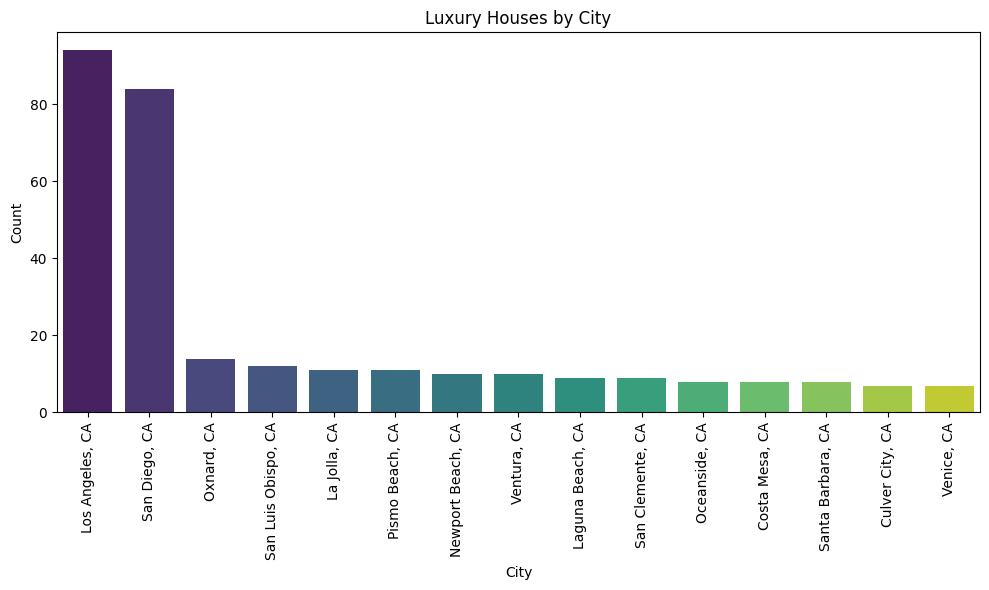

In [35]:
luxury_city = luxury["city"].value_counts().reset_index()
luxury_city.columns = ["city", "count"]
luxury_city

Top_luxury_city = luxury_city.sort_values(by="count", ascending=False).head(15)
Top_luxury_city

plt.figure(figsize=(10,6))
sns.barplot(Top_luxury_city, x ="city", y="count", palette="viridis")

plt.xlabel("City")
plt.ylabel("Count")
plt.title("Luxury Houses by City")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 5. Tabular Preprocessing

### Encoding

In [36]:
df

,image_id,street,city,city_encoded,bedrooms,bathrooms,sqft,price,Total_rooms,Price per Square Foot,sqft_per_room
0,0,1317 Van Buren Avenue,"Salton City, CA",317,3,2,1560,201900,5,129.423077,312.000000
1,1,124 C Street W,"Brawley, CA",48,3,2,713,228500,5,320.476858,142.600000
2,2,2304 Clark Road,"Imperial, CA",152,3,1,800,273950,4,342.437500,200.000000
3,3,755 Brawley Avenue,"Brawley, CA",48,3,1,1082,350000,4,323.475046,270.500000
4,4,2207 R Carrillo Court,"Calexico, CA",55,4,3,2547,385100,7,151.197487,363.857143
...,...,...,...,...,...,...,...,...,...,...,...
15469,15469,4156 Sterlingview Drive,"Moorpark, CA",227,5,4,4092,949000,9,231.915934,454.666667
15470,15470,4355 Avenida Prado,"Thousand Oaks, CA",372,5,3,2773,949900,8,342.553191,346.625000
15471,15471,12717 Koenigstein Rd Road,"Santa Paula, CA",338,3,2,1576,920000,5,583.756345,315.200000
15472,15472,36 Kunkle Street,"Oak View, CA",253,4,2,2086,997000,6,477.948226,347.666667


In [37]:
df.loc[df.city_encoded == 227]

,image_id,street,city,city_encoded,bedrooms,bathrooms,sqft,price,Total_rooms,Price per Square Foot,sqft_per_room
14604,14604,4809 Maureen Lane,"Moorpark, CA",227,6,3,3300,1250000,9,378.787879,366.666667
14624,14624,7032 Hogan Street,"Moorpark, CA",227,5,5,5851,1325000,10,226.457016,585.100000
14763,14763,13870 Saddleback Drive,"Moorpark, CA",227,4,4,3987,1550000,8,388.763481,498.375000
14779,14779,7342 Nicklaus Road,"Moorpark, CA",227,5,5,4967,1649000,10,331.991142,496.700000
14790,14790,8205 Waters Road,"Moorpark, CA",227,2,1,1200,1995000,3,1662.500000,400.000000
14843,14843,313 Whitney Avenue,"Moorpark, CA",227,3,2,1500,470000,5,313.333333,300.000000
14856,14856,238 Everett Street,"Moorpark, CA",227,3,2,1344,496999,5,369.790923,268.800000
14882,14882,4852 Penrose Avenue,"Moorpark, CA",227,3,2,1587,549000,5,345.935728,317.400000
14902,14902,238 Everett Street,"Moorpark, CA",227,3,2,1344,496999,5,369.790923,268.800000
14909,14909,13376 E Quail Summit Road,"Moorpark, CA",227,3,2,1018,525000,5,515.717092,203.600000


In [38]:
df.loc[df.city == "Moorpark, CA"]

,image_id,street,city,city_encoded,bedrooms,bathrooms,sqft,price,Total_rooms,Price per Square Foot,sqft_per_room
14604,14604,4809 Maureen Lane,"Moorpark, CA",227,6,3,3300,1250000,9,378.787879,366.666667
14624,14624,7032 Hogan Street,"Moorpark, CA",227,5,5,5851,1325000,10,226.457016,585.100000
14763,14763,13870 Saddleback Drive,"Moorpark, CA",227,4,4,3987,1550000,8,388.763481,498.375000
14779,14779,7342 Nicklaus Road,"Moorpark, CA",227,5,5,4967,1649000,10,331.991142,496.700000
14790,14790,8205 Waters Road,"Moorpark, CA",227,2,1,1200,1995000,3,1662.500000,400.000000
14843,14843,313 Whitney Avenue,"Moorpark, CA",227,3,2,1500,470000,5,313.333333,300.000000
14856,14856,238 Everett Street,"Moorpark, CA",227,3,2,1344,496999,5,369.790923,268.800000
14882,14882,4852 Penrose Avenue,"Moorpark, CA",227,3,2,1587,549000,5,345.935728,317.400000
14902,14902,238 Everett Street,"Moorpark, CA",227,3,2,1344,496999,5,369.790923,268.800000
14909,14909,13376 E Quail Summit Road,"Moorpark, CA",227,3,2,1018,525000,5,515.717092,203.600000


In [39]:
df.groupby("city")["city_encoded"].agg(lambda x: x.mode()[0]).sort_values(ascending =False)

,city_encoded
city,
"Yucca Valley, CA",414
"Yucaipa, CA",413
"Yorba Linda, CA",412
"Wrightwood, CA",411
"Woodland Hills, CA",410
...,...
"Agua Dulce, CA",4
"Agoura Hills, CA",3
"Adelanto, CA",2


### Drop Unnecessary columns

In [40]:
df2 = df.drop(columns=["street", "city", "image_id" , "Price per Square Foot" ])

In [41]:
df2.head(10)

,city_encoded,bedrooms,bathrooms,sqft,price,Total_rooms,sqft_per_room
0,317,3,2,1560,201900,5,312.000000
1,48,3,2,713,228500,5,142.600000
2,152,3,1,800,273950,4,200.000000
3,48,3,1,1082,350000,4,270.500000
4,55,4,3,2547,385100,7,363.857143
5,48,3,1,1082,350000,4,270.500000
6,55,4,3,2769,415000,7,395.571429
7,48,5,2,2600,545000,7,371.428571
8,48,5,2,2600,545000,7,371.428571
9,317,4,5,3932,690000,9,436.888889


### Splitting The Data

In [42]:
x = df2.drop(columns=["price"])
y = df2["price"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

### Scaling

In [43]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

## 6. Model 1: Random Forest Tabular Baseline

In [44]:
selected_model = RandomForestRegressor(random_state=42)

params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

random_search = RandomizedSearchCV(
    estimator=selected_model,
    param_distributions=params,
    cv=5,
    n_jobs=-1,
    scoring='neg_mean_absolute_error',
    random_state=42,
    verbose=2
)

random_search.fit(x_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='neg_mean_absolute_error',
                   verbose=2)

In [45]:
print("Best Parameters: ", random_search.best_params_)

Best Parameters:  {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}


In [46]:
model1 = random_search.best_estimator_
model1.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [47]:
y_pred = model1.predict(x_test)

### Random Forest Evaluation

The Random Forest model is a strong tabular baseline because it can learn non-linear relationships between price, sqft, rooms, bathrooms, and encoded city without needing many assumptions. I used R2 and MAE for evaluation: **R2** shows how much variance the model explains, while **MAE** shows the average prediction error in dollars.

This baseline is important because it tells us how much performance we can get from structured data alone before adding images. If the image model does not improve over this baseline, then the tabular features are probably carrying most of the useful signal.


In [48]:
print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2: 0.6016670071253389
MAE: 150641.27091155565


## 7. Image + Tabular Model

Images can provide useful information about house prices because they may show visual quality that is not captured in the CSV, such as architecture style, exterior condition, curb appeal, lighting, view, and whether the property looks renovated or neglected.

However, images should not replace tabular data. Price is strongly affected by location, sqft, bedrooms, and bathrooms, so the best approach is to combine both sources: use a CNN to extract image features and concatenate those features with scaled tabular features before the final regression layers.


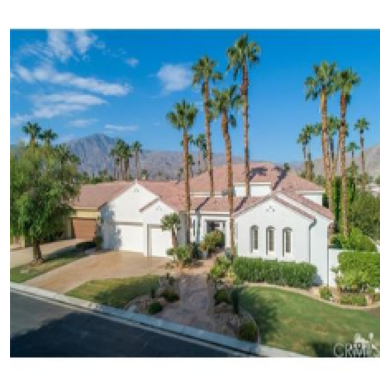

In [49]:
images_folder = os.path.join(data_path, "socal2")
if not os.path.exists(images_folder):
    images_folder = os.path.join(os.getcwd(), "socal2")

images_folder = os.path.join(images_folder, "socal_pics")

image_name = os.listdir(images_folder)[1]
image_path = os.path.join(images_folder, image_name)


img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224, 224))


plt.imshow(img)
plt.axis("off")
plt.show()

In [50]:
df_images = df2.copy()

df_images['image_path'] = [
    os.path.join(images_folder, f"{int(i)}.jpg")
    for i in df["image_id"].values
]

df_images.head()

,city_encoded,bedrooms,bathrooms,sqft,price,Total_rooms,sqft_per_room,image_path
0,317,3,2,1560,201900,5,312.000000,/root/.cache/kagglehub/datasets/ted8080/house-...
1,48,3,2,713,228500,5,142.600000,/root/.cache/kagglehub/datasets/ted8080/house-...
2,152,3,1,800,273950,4,200.000000,/root/.cache/kagglehub/datasets/ted8080/house-...
3,48,3,1,1082,350000,4,270.500000,/root/.cache/kagglehub/datasets/ted8080/house-...
4,55,4,3,2547,385100,7,363.857143,/root/.cache/kagglehub/datasets/ted8080/house-...


### Train, Validation, and Test Split

In [51]:
df_train, df_test = train_test_split(df_images, test_size=0.25, random_state=42)
df_test, df_valid = train_test_split(df_test, test_size=0.2, random_state=42)

df_train = df_train.copy()
df_valid = df_valid.copy()
df_test = df_test.copy()

In [52]:
df_train

,city_encoded,bedrooms,bathrooms,sqft,price,Total_rooms,sqft_per_room,image_path
9307,411,3,2,2502,489101,5,500.400000,/root/.cache/kagglehub/datasets/ted8080/house-...
9248,307,4,3,1895,439000,7,270.714286,/root/.cache/kagglehub/datasets/ted8080/house-...
10354,78,4,3,1573,774900,7,224.714286,/root/.cache/kagglehub/datasets/ted8080/house-...
12754,320,3,2,1941,735000,5,388.200000,/root/.cache/kagglehub/datasets/ted8080/house-...
7464,300,3,3,2940,749999,6,490.000000,/root/.cache/kagglehub/datasets/ted8080/house-...
...,...,...,...,...,...,...,...,...
5191,266,4,4,2243,1525000,8,280.375000,/root/.cache/kagglehub/datasets/ted8080/house-...
13418,326,4,3,3484,1199000,7,497.714286,/root/.cache/kagglehub/datasets/ted8080/house-...
5390,82,4,3,1550,250000,7,221.428571,/root/.cache/kagglehub/datasets/ted8080/house-...
860,193,3,2,1534,285000,5,306.800000,/root/.cache/kagglehub/datasets/ted8080/house-...


### Optional ImageDataGenerator Pipeline
This generator is kept for quick image experiments. The final EfficientNet model below uses the `tf.data` pipeline.

In [53]:
image_size = (224, 224)
batch_size = 32

train_gen = ImageDataGenerator(
    rescale=1/255.0,
    rotation_range=10,
    zoom_range=0.15,
    horizontal_flip=True,
    width_shift_range=0.08,
    height_shift_range=0.08,
    brightness_range=(0.85, 1.15),
    fill_mode="nearest"
)

test_gen = ImageDataGenerator(rescale=1/255.0)

train_generator = train_gen.flow_from_dataframe(
    df_train,
    x_col="image_path",
    y_col="price",
    target_size=image_size,
    batch_size=batch_size,
    color_mode="grayscale",
    shuffle=True,
    seed=SEED,
    class_mode="raw"
)

valid_generator = test_gen.flow_from_dataframe(
    df_valid,
    x_col="image_path",
    y_col="price",
    target_size=image_size,
    batch_size=batch_size,
    color_mode="grayscale",
    shuffle=False,
    class_mode="raw"
)

test_generator = test_gen.flow_from_dataframe(
    df_test,
    x_col="image_path",
    y_col="price",
    target_size=image_size,
    batch_size=batch_size,
    color_mode="grayscale",
    shuffle=False,
    class_mode="raw"
)

Found 11605 validated image filenames.
Found 774 validated image filenames.
Found 3095 validated image filenames.


### Feature Scaling and Target Scaling
The neural network predicts a scaled `log1p(price)` target. This keeps the output numerically stable, then evaluation converts predictions back to dollars.

In [54]:
feature = ["city_encoded","bedrooms","bathrooms","sqft","Total_rooms","sqft_per_room"]

scaler = StandardScaler()
df_train[feature] = scaler.fit_transform(df_train[feature])
df_valid[feature] = scaler.transform(df_valid[feature])
df_test[feature] = scaler.transform(df_test[feature])

df_train["price_log"] = np.log1p(df_train["price"])
df_valid["price_log"] = np.log1p(df_valid["price"])
df_test["price_log"] = np.log1p(df_test["price"])

target_scaler = StandardScaler()
df_train["price_log_scaled"] = target_scaler.fit_transform(df_train[["price_log"]]).ravel()
df_valid["price_log_scaled"] = target_scaler.transform(df_valid[["price_log"]]).ravel()
df_test["price_log_scaled"] = target_scaler.transform(df_test[["price_log"]]).ravel()

price_log_min = df_train["price_log"].min()
price_log_max = df_train["price_log"].max()

image_paths = df_train["image_path"].values
tabular_data = df_train[feature].values.astype("float32")
targets = df_train["price_log_scaled"].values.astype("float32")


### TensorFlow Dataset Pipeline

In [55]:
IMG_SIZE = (224, 224)

def load_data(image_path, tabular, target):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(
        img,
        channels=3
    )

    img = tf.image.resize(
        img,
        IMG_SIZE
    )

    # EfficientNet has its own preprocessing layer, so keep pixel values in 0-255.
    img = tf.cast(img, tf.float32)
    return (
        (img, tabular),
        target
    )


In [56]:
train_ds = tf.data.Dataset.from_tensor_slices((image_paths, tabular_data, targets))
train_ds = train_ds.map( load_data, num_parallel_calls=tf.data.AUTOTUNE )

BATCH_SIZE = 32

train_ds = (
    train_ds
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


# Validation Data
valid_ds = tf.data.Dataset.from_tensor_slices(
    (
        df_valid["image_path"].values,
        df_valid[feature].values.astype("float32"),
        df_valid["price_log_scaled"].values.astype("float32")
    )
)

valid_ds = (
    valid_ds
    .map(load_data)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


## Test Data
test_ds = tf.data.Dataset.from_tensor_slices(
    (
        df_test["image_path"].values,
        df_test[feature].values.astype("float32"),
        df_test["price_log_scaled"].values.astype("float32")
    )
)

test_ds = (
    test_ds
    .map(load_data)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

### Sanity Check

In [57]:
print("Train finite:", np.isfinite(df_train[feature + ["price_log", "price_log_scaled"]]).all().all())
print("Valid finite:", np.isfinite(df_valid[feature + ["price_log", "price_log_scaled"]]).all().all())
print("Test finite:", np.isfinite(df_test[feature + ["price_log", "price_log_scaled"]]).all().all())


Train finite: True
Valid finite: True
Test finite: True


### Build EfficientNet + Tabular Regression Model

I used **EfficientNetB3** as the image feature extractor because it is a pretrained CNN that can learn useful visual patterns with less data than training a CNN from scratch. The image branch extracts visual features, the tabular branch processes the structured columns, and both branches are joined using `Concatenate` before predicting price.

The model predicts a scaled `log1p(price)` target instead of raw price. I made this decision because house prices are highly skewed, and predicting raw dollars can make training unstable. After prediction, I convert the result back to real prices for R2 and MAE.


In [58]:
# img_shape = (224, 224, 3)

image_input = Input(shape=(224,224,3), name="image_input")

base_model = keras.applications.EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_tensor=image_input,
    pooling=None,
    name="efficientnetb3"
)
base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = BatchNormalization()(x)
x = Dense(
    256,
    activation="relu",
    kernel_regularizer=l2(0.0005))(x)
x = Dropout(0.3)(x)

tabular_input = Input(shape=(len(feature),), name="tabular_input")
t = Dense(64, activation="relu")(tabular_input)
t = BatchNormalization()(t)
t = Dense(32, activation="relu")(t)


combined = Concatenate()([x, t])
z = Dense(128, activation="relu")(combined)
z = Dropout(0.3)(z)
z = Dense(64, activation="relu")(z)

# Predict scaled log-price, not raw dollars.
output = Dense(1, bias_initializer=tf.keras.initializers.Constant(0.0))(z)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [59]:
model = Model(inputs=[image_input, tabular_input], outputs=output)
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=tf.keras.losses.Huber(),
    metrics=["mae"]
)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ image_input[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        960 │ block1a_se_excit

 Total params: 11,231,248 (42.84 MB)

 Trainable params: 444,513 (1.70 MB)

 Non-trainable params: 10,786,735 (41.15 MB)

### Train Frozen EfficientNet Head

In [60]:
early_stop2 = EarlyStopping(
    monitor="val_mae",
    patience=5,
    restore_best_weights=True,
    min_delta=0.001,
    mode="min",
    verbose=1
)

reduce_lr2 = ReduceLROnPlateau(
    monitor="val_mae",
    patience=2,
    factor=0.3,
    min_lr=1e-6,
    mode="min",
    verbose=1
)

model_CP2 = ModelCheckpoint(
    "best_efficientnet.keras",
    monitor="val_mae",
    mode="min",
    save_best_only=True,
    verbose=1
)

# First train only the new regression head.
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=30,
    callbacks=[model_CP2, reduce_lr2, early_stop2]
)

Epoch 1/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - loss: 0.7143 - mae: 0.8775
Epoch 1: val_mae improved from None to 0.69559, saving model to best_efficientnet.keras

Epoch 1: finished saving model to best_efficientnet.keras
363/363 ━━━━━━━━━━━━━━━━━━━━ 143s 231ms/step - loss: 0.6507 - mae: 0.8046 - val_loss: 0.5594 - val_mae: 0.6956 - learning_rate: 1.0000e-04
Epoch 2/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.5607 - mae: 0.6995
Epoch 2: val_mae improved from 0.69559 to 0.64635, saving model to best_efficientnet.keras

Epoch 2: finished saving model to best_efficientnet.keras
363/363 ━━━━━━━━━━━━━━━━━━━━ 31s 84ms/step - loss: 0.5504 - mae: 0.6876 - val_loss: 0.5164 - val_mae: 0.6463 - learning_rate: 1.0000e-04
Epoch 3/30
362/363 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.5282 - mae: 0.6662
Epoch 3: val_mae improved from 0.64635 to 0.62691, saving model to best_efficientnet.keras

Epoch 3: finished saving model to best_efficientnet.keras
363/363 ━━━━━━━━━━━━━━━━━━━━ 4

### Evaluate Before Fine-Tuning

Before fine-tuning, only the new regression head is trained while EfficientNet stays frozen. This gives a stable first stage where the model learns how to connect pretrained image features and tabular data to house price.

The main thing I evaluate here is whether the combined image + tabular model is learning a reasonable price scale. Very negative R2 or extremely large MAE usually means the target scaling or inverse transformation is wrong, so I fixed the evaluation to convert from scaled log-price back to dollar price correctly.


In [61]:
train_score = model.evaluate(train_ds, verbose=1)
valid_score = model.evaluate(valid_ds, verbose=1)
test_score = model.evaluate(test_ds, verbose=1)

print(f"Train Score = {train_score}")
print(f"Validation Score = {valid_score}")
print(f"Test Score = {test_score}")

363/363 ━━━━━━━━━━━━━━━━━━━━ 34s 92ms/step - loss: 0.3094 - mae: 0.4366
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 0.3914 - mae: 0.5548
97/97 ━━━━━━━━━━━━━━━━━━━━ 23s 234ms/step - loss: 0.3876 - mae: 0.5497
Train Score = [0.3094033896923065, 0.4365817904472351]
Validation Score = [0.3914308249950409, 0.5548083186149597]
Test Score = [0.3876079022884369, 0.5497388243675232]


In [62]:
y_pred_scaled = model.predict(test_ds).reshape(-1)
y_pred_log = target_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).reshape(-1)
y_pred_log = np.clip(y_pred_log, price_log_min, price_log_max)

y_test2 = df_test["price"].values.astype("float32")
y_pred_price = np.expm1(y_pred_log)
y_pred_price = np.maximum(y_pred_price, 0)

97/97 ━━━━━━━━━━━━━━━━━━━━ 28s 181ms/step


In [63]:
print("R2:", r2_score(y_test2, y_pred_price))
print("MAE:", mean_absolute_error(y_test2, y_pred_price))

R2: 0.42842793464660645
MAE: 193406.015625


In [64]:
print("Max y_test2:", np.max(y_test2))
print("Max y_pred:", np.max(y_pred_price))

print("Min y_test2:", np.min(y_test2))
print("Min y_pred:", np.min(y_pred_price))

Max y_test2: 2000000.0
Max y_pred: 2000000.4
Min y_test2: 195000.0
Min y_pred: 216901.42


### Fine-Tuning Setup

In [65]:
base_model.trainable = True

# سيب آخر 80 Layer فقط للتدريب
for layer in base_model.layers[:-80]:
    layer.trainable = False

# اقفل BatchNorm
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False


In [66]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss=tf.keras.losses.Huber(),
    metrics=["mae"]
)


In [67]:
early_stop = EarlyStopping(
    monitor="val_mae",
    patience=5,
    restore_best_weights=True,
    mode="min",
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_mae",
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    mode="min",
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_finetuned_model.keras",
    monitor="val_mae",
    save_best_only=True,
    mode="min",
    verbose=1
)


### Train Fine-Tuned Model

In [68]:
fine_tune_history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=15,
    callbacks=[
        checkpoint,
        reduce_lr,
        early_stop
    ]
)


Epoch 1/15
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - loss: 0.3636 - mae: 0.5207
Epoch 1: val_mae improved from None to 0.55525, saving model to best_finetuned_model.keras

Epoch 1: finished saving model to best_finetuned_model.keras
363/363 ━━━━━━━━━━━━━━━━━━━━ 137s 237ms/step - loss: 0.3621 - mae: 0.5193 - val_loss: 0.3910 - val_mae: 0.5552 - learning_rate: 1.0000e-05
Epoch 2/15
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.3591 - mae: 0.5161
Epoch 2: val_mae improved from 0.55525 to 0.55076, saving model to best_finetuned_model.keras

Epoch 2: finished saving model to best_finetuned_model.keras
363/363 ━━━━━━━━━━━━━━━━━━━━ 43s 114ms/step - loss: 0.3560 - mae: 0.5116 - val_loss: 0.3876 - val_mae: 0.5508 - learning_rate: 1.0000e-05
Epoch 3/15
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 0.3512 - mae: 0.5046
Epoch 3: val_mae improved from 0.55076 to 0.54655, saving model to best_finetuned_model.keras

Epoch 3: finished saving model to best_finetuned_model.keras
363/363 ━

### Evaluate After Fine-Tuning

After fine-tuning, the last EfficientNet layers are allowed to adapt to this housing image dataset. I keep BatchNormalization layers frozen because updating them on a relatively small dataset can make training unstable.

The expected challenge is that images may add only a small improvement compared with location and sqft. Other challenges include noisy images, repeated or missing addresses, outliers in price, uneven city distribution, and the high training cost of CNN models. Because of this, I compare the image + tabular model against the Random Forest baseline instead of assuming the deep learning model is automatically better.


In [69]:
train_score = model.evaluate(train_ds, verbose=1)
valid_score = model.evaluate(valid_ds, verbose=1)
test_score = model.evaluate(test_ds, verbose=1)

print(f"Train Score = {train_score}")
print(f"Validation Score = {valid_score}")
print(f"Test Score = {test_score}")


363/363 ━━━━━━━━━━━━━━━━━━━━ 35s 92ms/step - loss: 0.2433 - mae: 0.3274
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.3698 - mae: 0.5271
97/97 ━━━━━━━━━━━━━━━━━━━━ 13s 132ms/step - loss: 0.3610 - mae: 0.5134
Train Score = [0.24334357678890228, 0.3274100720882416]
Validation Score = [0.36978933215141296, 0.5271463394165039]
Test Score = [0.3609890937805176, 0.5133514404296875]


In [70]:
y_pred_scaled = model.predict(test_ds).reshape(-1)
y_pred_log = target_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).reshape(-1)
y_pred_log = np.clip(y_pred_log, price_log_min, price_log_max)

y_test2 = df_test["price"].values.astype("float32")
y_pred_price = np.expm1(y_pred_log)
y_pred_price = np.maximum(y_pred_price, 0)


97/97 ━━━━━━━━━━━━━━━━━━━━ 27s 175ms/step


In [71]:
print("R2:", r2_score(y_test2, y_pred_price))
print("MAE:", mean_absolute_error(y_test2, y_pred_price))


R2: 0.4658581018447876
MAE: 182474.6875
